In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv(r"C:\Users\lahar\OneDrive\Documents\Wine_Quality_Prediction_Using_Machine Learning\Data\winequality.csv")

In [14]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red


In [15]:
df.shape

(6497, 14)

In [16]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
good                    0
color                   0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  good                  6497 non-null   int64  
 13  color                 6497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 710.7+ KB


In [18]:
# input(x)
X = df.drop("quality", axis=1)

In [19]:
# Target (y)
y = df["quality"]

### Input Variables:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- good
- color

### Target Variable:
- quality

### Identify ML Task
Since the target variable is wine quality (quality classes), this is a Classification Machine Learning problem.

### Evaluation Metric
The evaluation metric used is Accuracy Score because it is a classification task.

In [20]:
## Encode the 'color' Column

# Check unique values:

df["color"].unique()

array(['red', 'white'], dtype=object)

In [21]:
# encode
le = LabelEncoder()

X["color"] = le.fit_transform(X["color"])

In [22]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,good,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0


In [23]:
# split dataset 75:25
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [24]:
# Standardize the Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
# Check Shapes
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4872, 13)
(1625, 13)
(4872,)
(1625,)


## K-Nearest Neighbors (KNN)

In [26]:
# Train the Model
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
from sklearn.neighbors import KNeighborsClassifier

In [28]:
print(X_train.shape)
print(X_test.shape)

(4872, 13)
(1625, 13)


In [29]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
# Predict

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_knn
})

prediction_df.head(10)

,Actual,Predicted
0,8,7
1,5,5
2,7,7
3,6,5
4,6,5
5,6,6
6,5,5
7,6,6
8,5,5
9,7,7


In [31]:
import pandas as pd

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [20]:
# Accuracy
knn_acc = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.6824615384615385


In [21]:
# Classification Report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           3       0.25      0.11      0.15         9
           4       0.21      0.11      0.14        57
           5       0.58      0.63      0.60       518
           6       0.72      0.71      0.71       738
           7       0.87      0.96      0.91       259
           8       0.40      0.14      0.21        43
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1625
   macro avg       0.43      0.38      0.39      1625
weighted avg       0.67      0.68      0.67      1625



C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


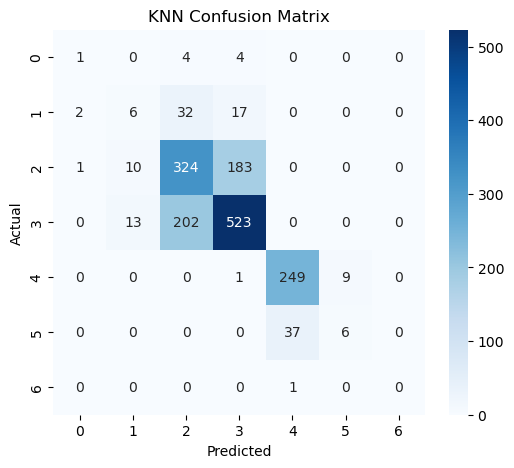

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Logistic Regression

In [40]:
# Train
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
# Predict
y_pred_lr = lr.predict(X_test)
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

prediction_df.head(10)

,Actual,Predicted
0,8,7
1,5,5
2,7,7
3,6,6
4,6,5
5,6,6
6,5,6
7,6,6
8,5,5
9,7,7


In [61]:
# Accuracy
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.6824615384615385


In [27]:
# classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.80      0.07      0.13        57
           5       0.56      0.61      0.59       518
           6       0.70      0.72      0.71       738
           7       0.85      1.00      0.92       259
           8       0.00      0.00      0.00        43
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1625
   macro avg       0.42      0.34      0.34      1625
weighted avg       0.66      0.68      0.66      1625



C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


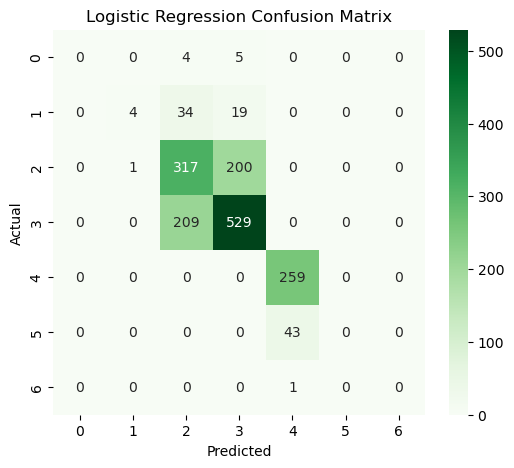

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Support Vector Machine (SVM)

In [49]:
# Train
svm = SVC()
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [51]:
y_pred_svm = svm.predict(X_test)

In [52]:
# Prediction
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})

prediction_df.head(10)

,Actual,Predicted
0,8,7
1,5,5
2,7,7
3,6,5
4,6,5
5,6,6
6,5,6
7,6,6
8,5,5
9,7,7


In [31]:
# Accuracy
svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.707076923076923


In [32]:
# Classification Report
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       1.00      0.02      0.03        57
           5       0.59      0.67      0.63       518
           6       0.74      0.74      0.74       738
           7       0.85      1.00      0.92       259
           8       0.00      0.00      0.00        43
           9       0.00      0.00      0.00         1

    accuracy                           0.71      1625
   macro avg       0.45      0.35      0.33      1625
weighted avg       0.69      0.71      0.68      1625



C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


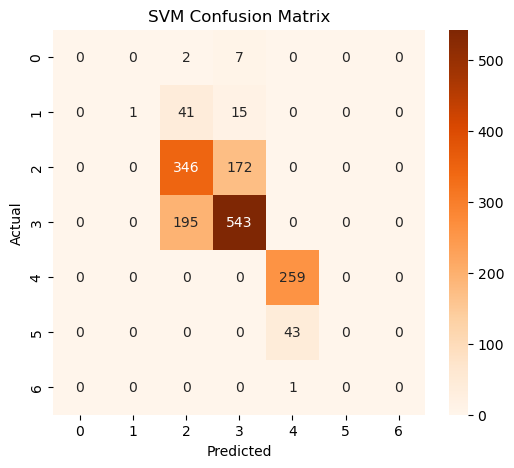

In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Decision Tree

In [54]:
# Train
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
# Predict
y_pred_dt = dt.predict(X_test)
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

prediction_df.head(10)

,Actual,Predicted
0,8,7
1,5,5
2,7,7
3,6,6
4,6,5
5,6,6
6,5,6
7,6,6
8,5,5
9,7,8


In [37]:
# Accuracy
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7107692307692308


In [38]:
# Classification Report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.22      0.23      0.22        57
           5       0.65      0.68      0.66       518
           6       0.76      0.73      0.75       738
           7       0.91      0.87      0.89       259
           8       0.39      0.49      0.43        43
           9       0.00      0.00      0.00         1

    accuracy                           0.71      1625
   macro avg       0.42      0.43      0.42      1625
weighted avg       0.72      0.71      0.71      1625



C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


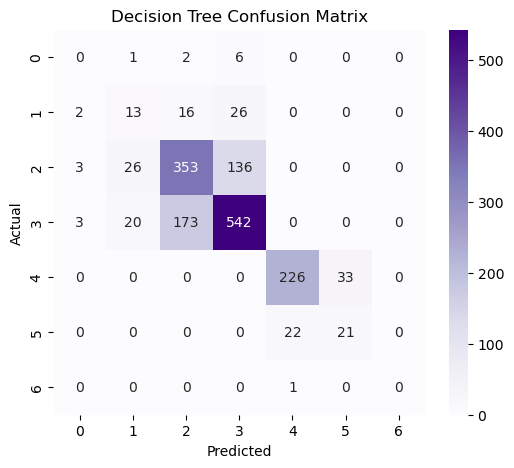

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [56]:
# Train
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
# Predict
y_pred_rf = rf.predict(X_test)
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

prediction_df.head(10)

,Actual,Predicted
0,8,7
1,5,5
2,7,7
3,6,5
4,6,5
5,6,6
6,5,5
7,6,6
8,5,5
9,7,7


In [42]:
# Accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7864615384615384


In [43]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.88      0.12      0.22        57
           5       0.70      0.75      0.73       518
           6       0.81      0.82      0.81       738
           7       0.90      1.00      0.95       259
           8       0.94      0.35      0.51        43
           9       0.00      0.00      0.00         1

    accuracy                           0.79      1625
   macro avg       0.60      0.44      0.46      1625
weighted avg       0.79      0.79      0.77      1625



C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lahar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


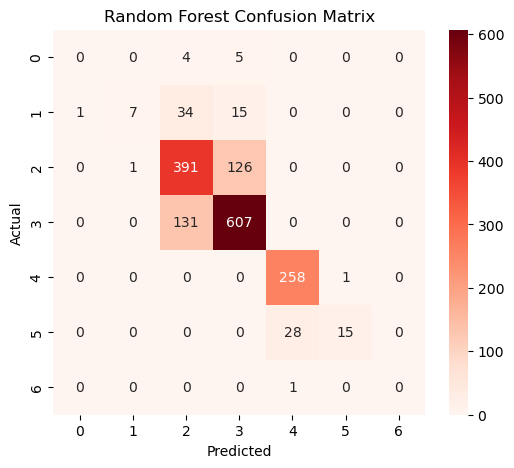

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
# compare all models
accuracy = pd.DataFrame({
    "Algorithm": [
        "KNN",
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        knn_acc,
        lr_acc,
        svm_acc,
        dt_acc,
        rf_acc
    ]
})

accuracy

,Algorithm,Accuracy
0,KNN,0.682462
1,Logistic Regression,0.682462
2,SVM,0.707077
3,Decision Tree,0.710769
4,Random Forest,0.786462


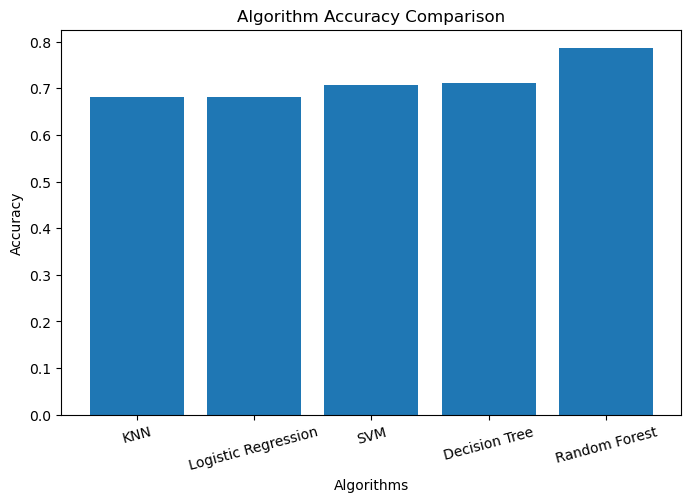

In [46]:
# Plot Accuracy Comparison
plt.figure(figsize=(8,5))

plt.bar(accuracy["Algorithm"], accuracy["Accuracy"])

plt.title("Algorithm Accuracy Comparison")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()


In [47]:
# Find the Best Model
best_model = accuracy.loc[accuracy["Accuracy"].idxmax()]

print(best_model)

Algorithm    Random Forest
Accuracy          0.786462
Name: 4, dtype: object


## Conclusion
- Five machine learning algorithms were trained and evaluated for predicting wine quality: KNN, Logistic Regression, SVM, Decision Tree, and Random Forest. Their performances were compared using Accuracy Score, as required for this classification task. The algorithm with the highest accuracy was selected as the best model for predicting wine quality. This model can help wineries improve quality control, maintain product consistency, and support data-driven production decisions.